# Reference-free track: rubric results

This notebook loads the numeric rubric scores from `ref_free_track_structured_numeric.json` and generates a multi-panel bar chart.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ---- CONFIG ----
DATA_PATH = Path("ref_free_track_structured_numeric.json")

# Choose how the "Average (All Languages)" panel is computed:
# - "micro": concatenate all doc-level points across languages (each doc counts equally)
# - "macro": compute per-language means, then average those means (each language counts equally)
AGGREGATION = "micro"  # "micro" or "macro"

assert DATA_PATH.exists(), f"Missing data file: {DATA_PATH}"
payload = json.loads(DATA_PATH.read_text(encoding="utf-8"))

df_judge = pd.DataFrame(payload["data"]["judge"])
df_human = pd.DataFrame(payload["data"]["human"])

CRITERIA = ["meaning", "tone", "readability"]
DISPLAY = ["Correctness", "Tone/Style", "Readability", "Overall"]


In [3]:
# ---- BUILD DOC-LEVEL MATRICES ----
# For humans: average across evaluators per (language, system, doc_id) so each excerpt has equal weight.
human_doc = df_human.groupby(["language","system","doc_id"], as_index=False)[CRITERIA].mean()

# Judge is already one score per doc; keep the same structure.
judge_doc = df_judge.groupby(["language","system","doc_id"], as_index=False)[CRITERIA].mean()

def add_overall(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["overall"] = df[CRITERIA].mean(axis=1)
    return df

human_doc = add_overall(human_doc)
judge_doc = add_overall(judge_doc)

ALL_METRICS = CRITERIA + ["overall"]


In [4]:
# ---- QUICK SANITY CHECKS ----
# (1) expected judge shape: 7 languages × 2 systems × 6 docs = 84
print("Judge rows:", len(judge_doc), " | expected:", 7*2*6)

# (2) detect identical sequences (often indicates copy/paste issues)
def seq_signature(df, lang, system):
    g = df[(df.language==lang) & (df.system==system)].sort_values("doc_id")
    return tuple(g[ALL_METRICS].to_numpy().flatten().tolist())

seen = {}
dups = []
for lang in sorted(judge_doc.language.unique()):
    for system in ["gpt4","azure"]:
        sig = seq_signature(judge_doc, lang, system)
        if sig in seen:
            dups.append((seen[sig], (lang, system)))
        else:
            seen[sig] = (lang, system)

print("Potential duplicate judge sequences:", dups if dups else "None detected")


Judge rows: 84  | expected: 84
Potential duplicate judge sequences: None detected


In [5]:
# ---- PREPARE PLOT DATA ----

LANG_ORDER = ["German","Turkish","English","Polish","Spanish","Arabic","Ukrainian"]

def get_matrix(df: pd.DataFrame, lang: str, system: str) -> np.ndarray:
    g = df[(df.language==lang) & (df.system==system)].sort_values("doc_id")
    # shape: (n_docs, 4)
    return g[ALL_METRICS].to_numpy()

def build_item(lang: str):
    return {
        "expert_azure":   get_matrix(human_doc, lang, "azure"),
        "gptjudge_azure": get_matrix(judge_doc, lang, "azure"),
        "expert_gpt":     get_matrix(human_doc, lang, "gpt4"),
        "gptjudge_gpt":   get_matrix(judge_doc, lang, "gpt4"),
    }

items = [(lang, build_item(lang)) for lang in LANG_ORDER]

def aggregate_all_languages(items, mode="micro"):
    if mode == "micro":
        # Concatenate doc-level points across languages
        out = {}
        for key in ["expert_azure","gptjudge_azure","expert_gpt","gptjudge_gpt"]:
            out[key] = np.concatenate([d[key] for _, d in items], axis=0)
        return out

    if mode == "macro":
        # Per-language means, then average those means (equal language weight)
        out = {}
        for key in ["expert_azure","gptjudge_azure","expert_gpt","gptjudge_gpt"]:
            per_lang_means = np.stack([np.mean(d[key], axis=0) for _, d in items], axis=0)  # (n_lang, 4)
            # for plotting: treat the per-language means as samples (so SD reflects cross-language variation)
            out[key] = per_lang_means
        return out

    raise ValueError("mode must be 'micro' or 'macro'")

items.append(("Average (All Languages)", aggregate_all_languages(items[:-1], mode=AGGREGATION)))


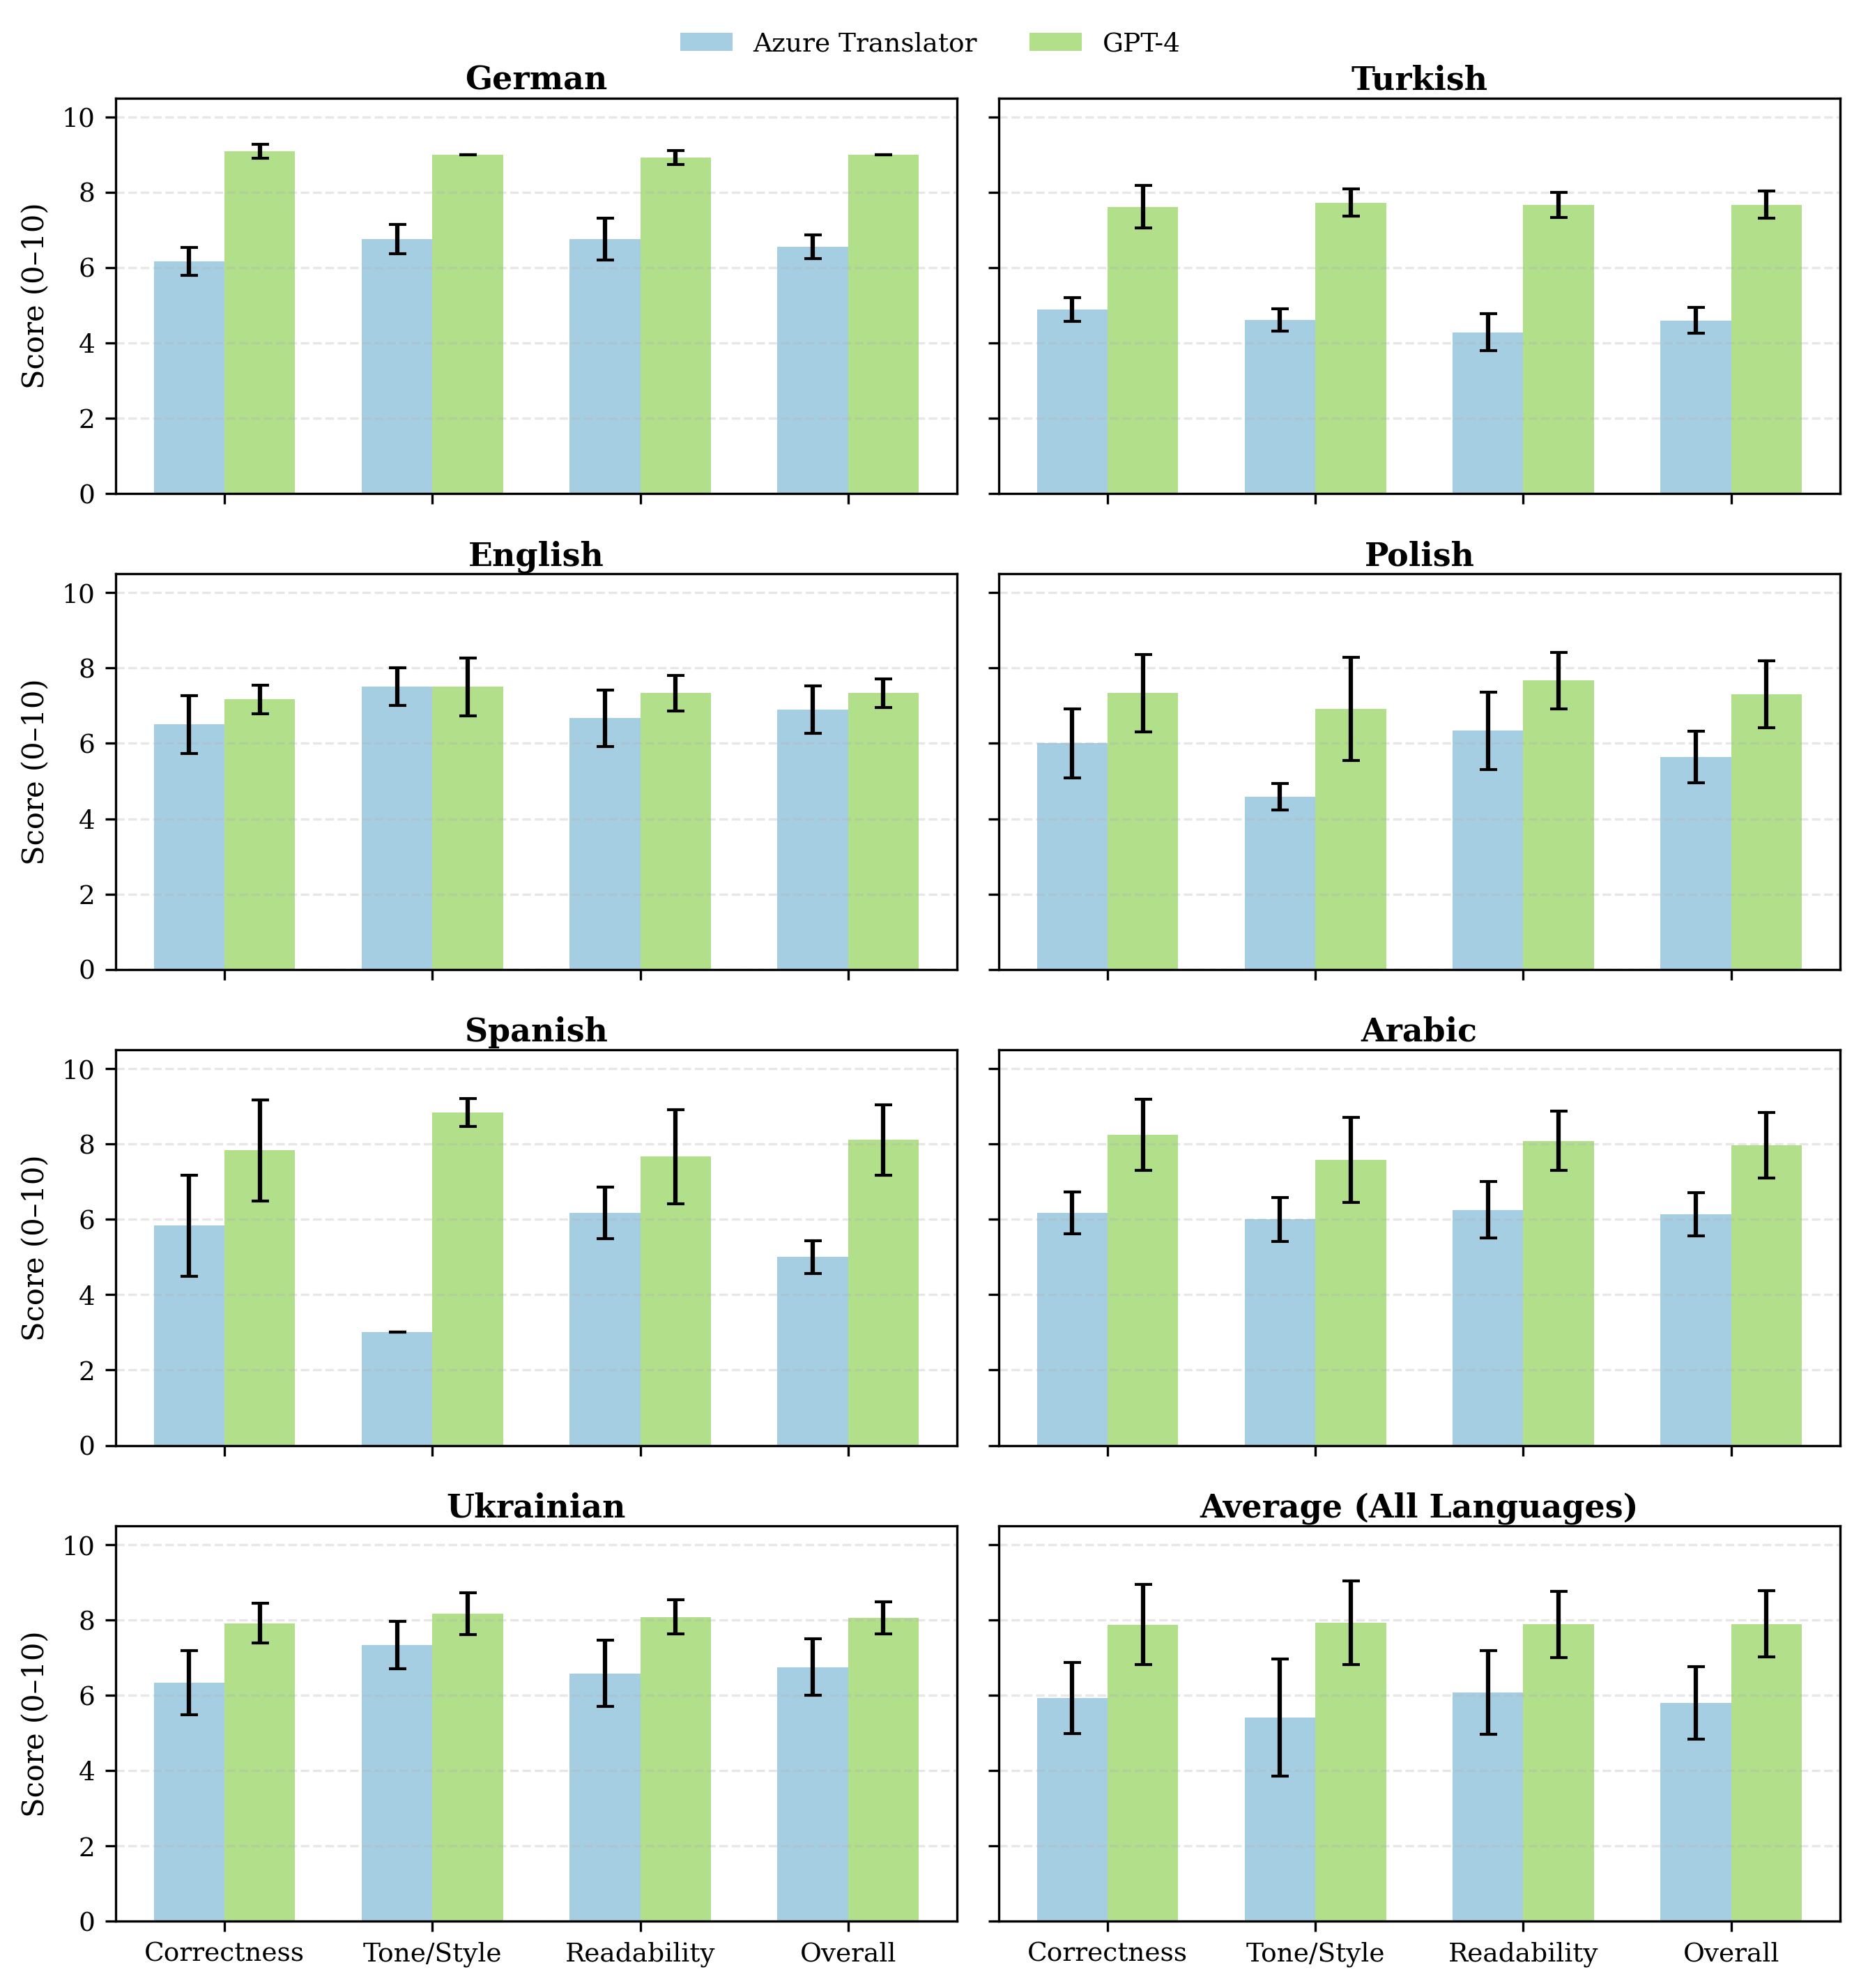

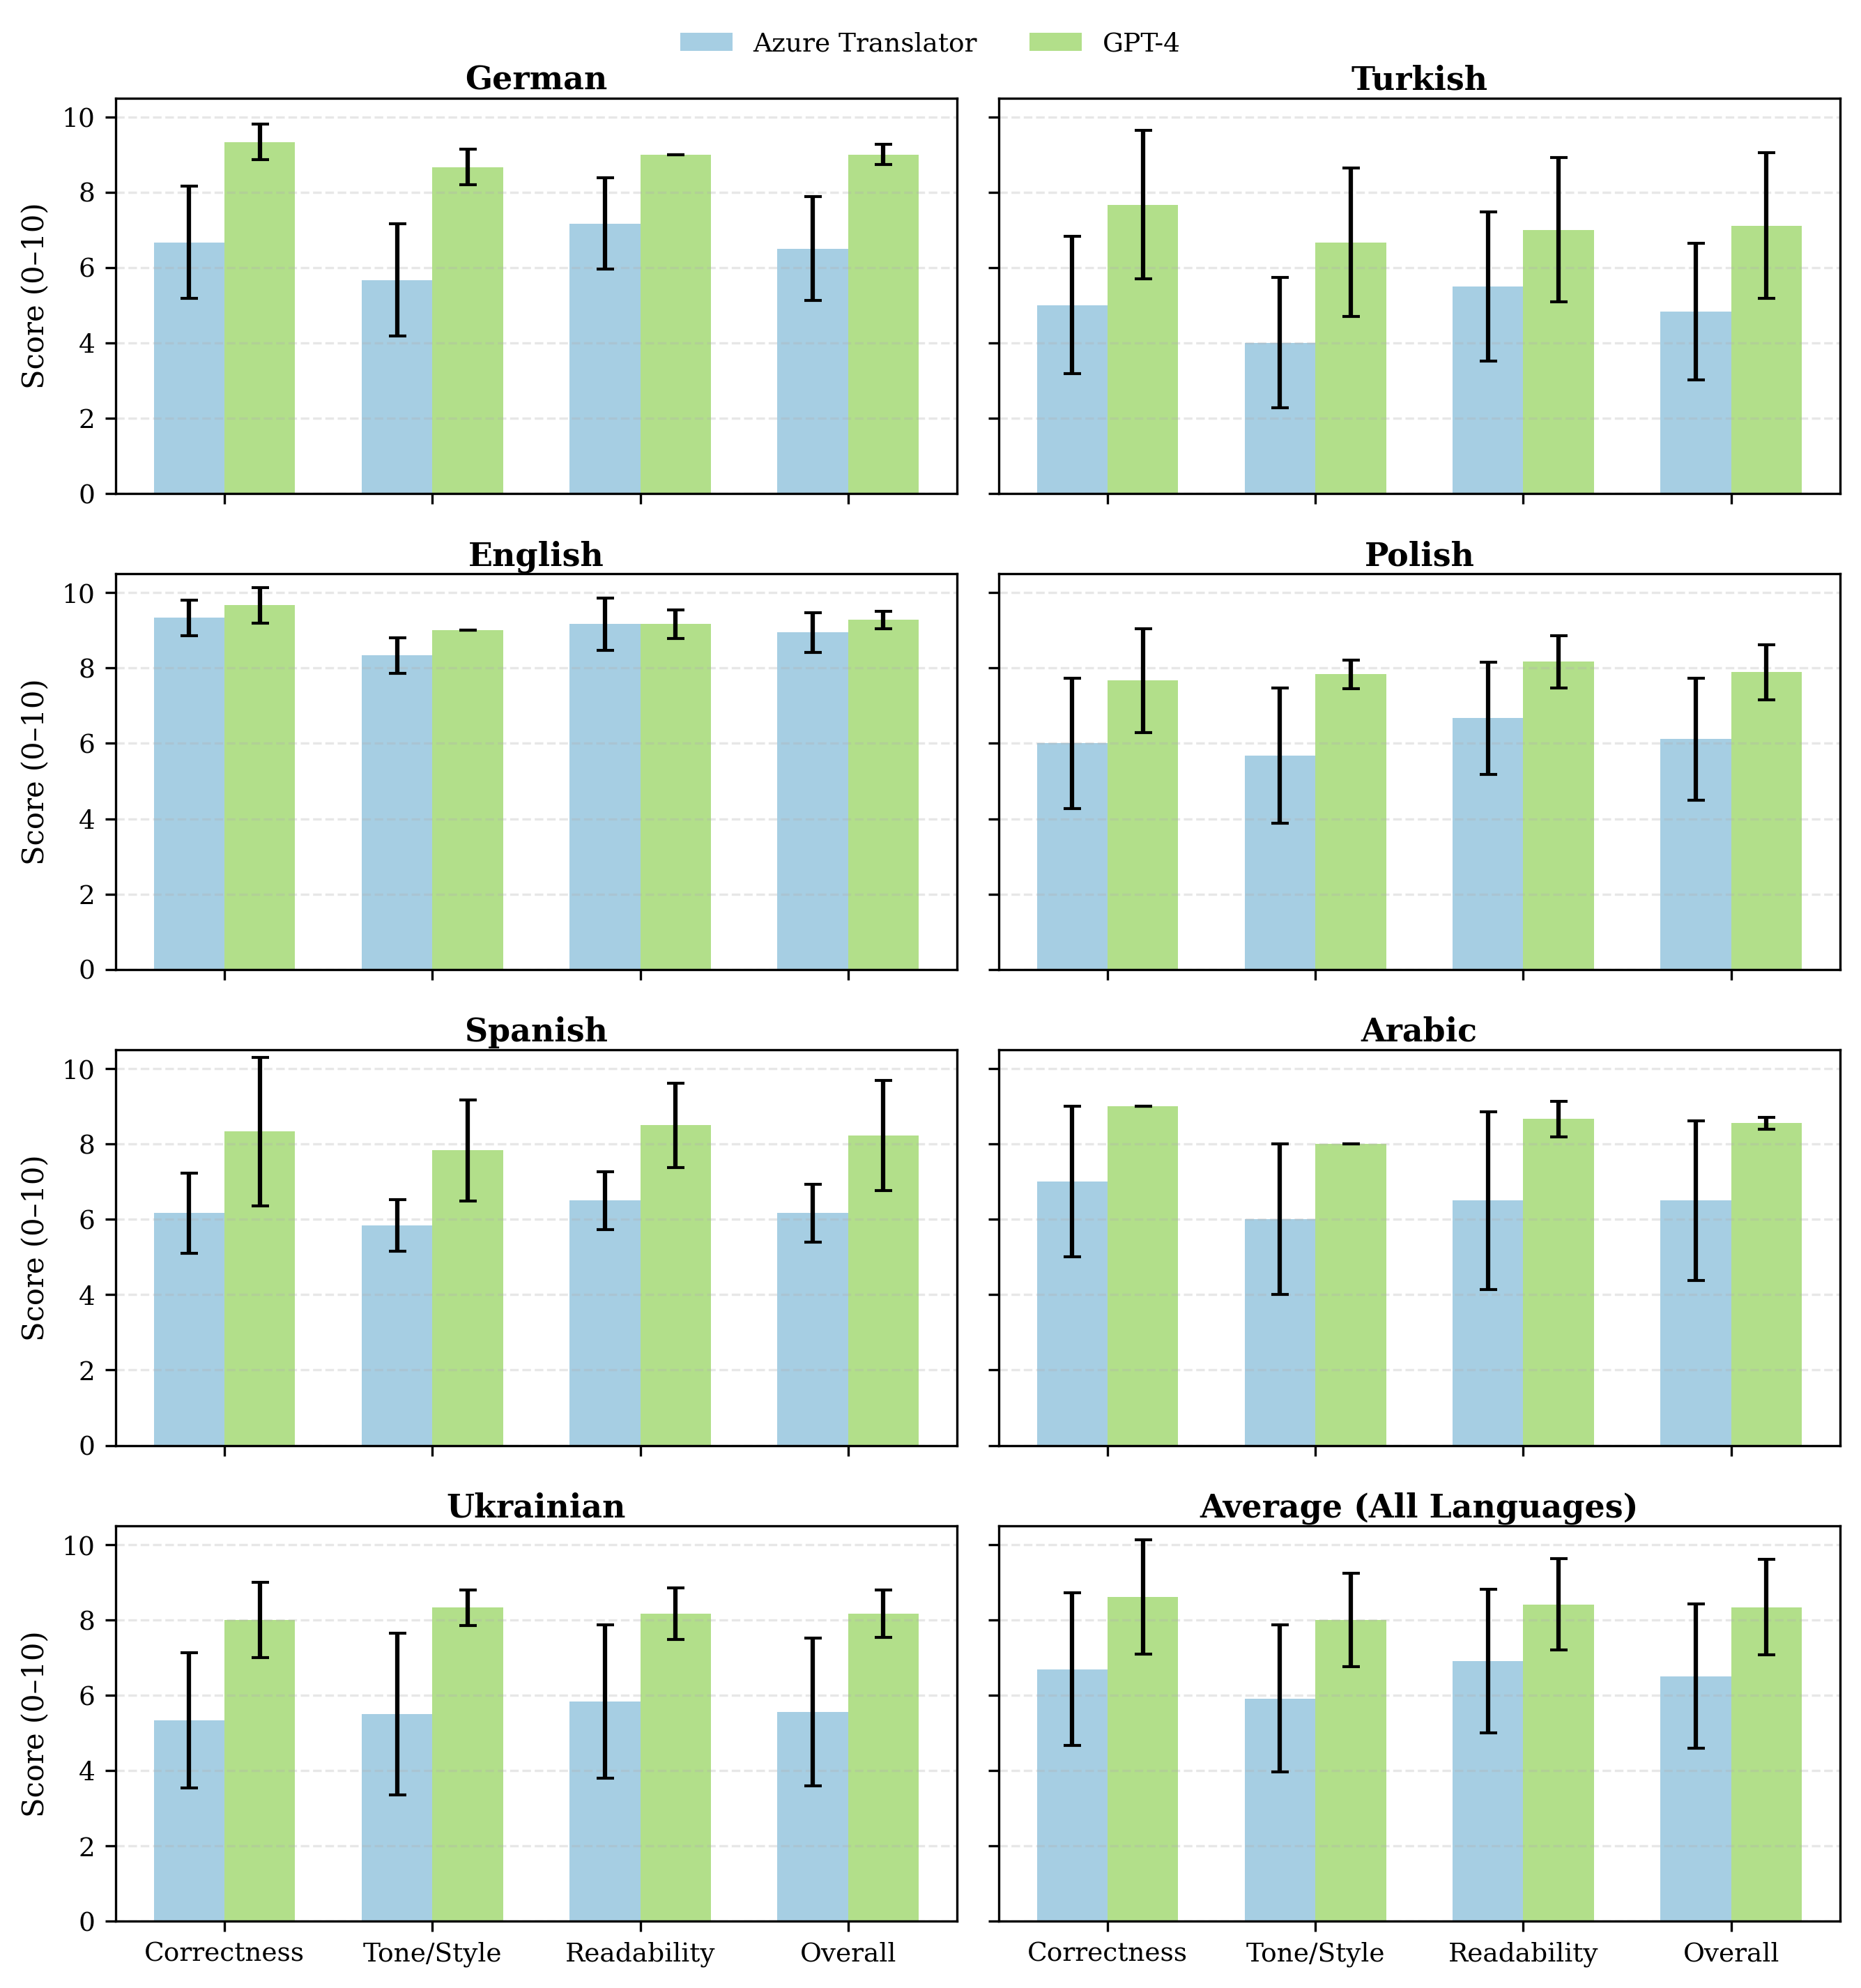

In [6]:
colors = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c']  # light blue, dark blue, light green, dark green


# ---- PLOT ----
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300,
})

x = np.arange(len(ALL_METRICS))  # 3 rubric categories + Overall


def mean_std(arr: np.ndarray):
    return np.mean(arr, axis=0), np.std(arr, axis=0, ddof=0)


def plot_score_figure(series_specs, width: float = 0.34):
    fig, axs = plt.subplots(4, 2, figsize=(9.0, 10.0), sharey=True, sharex=False)
    axs = axs.flatten()
    offsets = np.linspace(-width / 2, width / 2, num=len(series_specs))
    handles = None

    for i, (title, data_dict) in enumerate(items):
        ax = axs[i]
        bar_handles = []

        for offset, (key, label, color) in zip(offsets, series_specs):
            mean_vals, std_vals = mean_std(data_dict[key])
            bars = ax.bar(x + offset, mean_vals, width, yerr=std_vals, capsize=3, label=label, color=color)
            bar_handles.append(bars)

        ax.set_title(title, fontweight="bold", pad=3)
        ax.set_ylim(0, 10.5)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        if i >= 6:
            ax.set_xticks(x)
            ax.set_xticklabels(DISPLAY, rotation=0)
        else:
            ax.set_xticks(x)
            ax.set_xticklabels([])

        if i % 2 == 0:
            ax.set_ylabel("Score (0–10)")

        if handles is None:
            handles = bar_handles

    labels = [h.get_label() for h in handles]
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.952), ncol=len(series_specs), frameon=False)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()
    return fig


native_fig = plot_score_figure(
    [
        ("expert_azure", "Azure Translator", colors[0]),
        ("expert_gpt", "GPT-4", colors[2]),
    ],
)

judge_fig = plot_score_figure(
    [
        ("gptjudge_azure", "Azure Translator", colors[0]),
        ("gptjudge_gpt", "GPT-4", colors[2]),
    ],
)


In [7]:
# ---- OPTIONAL: SAVE FIGURES ----
# If you want to save for the paper, uncomment and run:
# native_out_path = Path("reference-free-results-native-speaker-with-overall.png")
# judge_out_path = Path("reference-free-results-llm-judge-with-overall.png")
# native_fig.savefig(native_out_path, bbox_inches="tight")
# judge_fig.savefig(judge_out_path, bbox_inches="tight")
# print("Saved:", native_out_path.resolve())
# print("Saved:", judge_out_path.resolve())


## Notes

- “Overall” is computed **per excerpt** as the mean of the three rubric dimensions, then aggregated across excerpts (mean ± 1 SD).  
- This avoids a common pitfall: averaging already-aggregated means, which hides within-excerpt variation.
- For equal language weight in the “Average (All Languages)” panel, set `AGGREGATION="macro"`; if you prefer equal excerpt weight, keep `AGGREGATION="micro"`.

